In [12]:
import numpy as np
import pandas as pd
from scipy.optimize import nnls, minimize

df = pd.read_csv("data.csv", index_col=0)
df

,PSC,JUNTS,ERC,PP,VOX,COMUNS,CUP,ALIANÇA.CAT,Altres,Cs,Abstenció
1980,0.138185,0.171275,0.054873,0.014556,0.000000,0.115557,0.000000,0.000000,0.117144,0.000000,0.388410
1984,0.193811,0.301318,0.028411,0.049647,0.000000,0.035962,0.000000,0.000000,0.031802,0.000000,0.359048
1988,0.177197,0.272179,0.024616,0.031648,0.000000,0.046166,0.000000,0.000000,0.039541,0.000000,0.408652
1992,0.152089,0.255296,0.043962,0.032968,0.000000,0.035913,0.000000,0.000000,0.025621,0.000000,0.454152
1995,0.159822,0.263467,0.061096,0.084246,0.000000,0.062607,0.000000,0.000000,0.005756,0.000000,0.363006
1999,0.227821,0.226843,0.052261,0.057211,0.000000,0.015129,0.000000,0.000000,0.016845,0.000000,0.403890
2003,0.198586,0.196993,0.104874,0.075627,0.000000,0.046480,0.000000,0.000000,0.008517,0.000000,0.368922
2006,0.153722,0.180767,0.080571,0.060980,0.000000,0.054760,0.000000,0.000000,0.013357,0.017425,0.438418
2010,0.111491,0.234199,0.042640,0.075148,0.000000,0.044927,0.000000,0.000000,0.061473,0.020696,0.409426
2012,0.101217,0.215104,0.095984,0.091014,0.000000,0.069380,0.024398,0.000000,0.040548,0.053099,0.309256


In [13]:
df["Dreta espanyola"] = df["PP"] + df["Cs"] + df["VOX"]
df["Dreta catalana"] = df["JUNTS"] + df["ALIANÇA.CAT"]
df["Esquerra catalana"] = df["ERC"] + df["CUP"]
df["Esquerra espanyola"] = df["PSC"] + df["COMUNS"]
df.drop(columns=["PP", "Cs", "VOX", "JUNTS", "ALIANÇA.CAT", "ERC", "CUP", "PSC", "COMUNS"], inplace=True)
df

,Altres,Abstenció,Dreta espanyola,Dreta catalana,Esquerra catalana,Esquerra espanyola
1980,0.117144,0.388410,0.014556,0.171275,0.054873,0.253742
1984,0.031802,0.359048,0.049647,0.301318,0.028411,0.229773
1988,0.039541,0.408652,0.031648,0.272179,0.024616,0.223363
1992,0.025621,0.454152,0.032968,0.255296,0.043962,0.188002
1995,0.005756,0.363006,0.084246,0.263467,0.061096,0.222429
1999,0.016845,0.403890,0.057211,0.226843,0.052261,0.242950
2003,0.008517,0.368922,0.075627,0.196993,0.104874,0.245066
2006,0.013357,0.438418,0.078405,0.180767,0.080571,0.208482
2010,0.061473,0.409426,0.095844,0.234199,0.042640,0.156418
2012,0.040548,0.309256,0.144113,0.215104,0.120382,0.170597


In [14]:
list(df.columns)

['Altres',
 'Abstenció',
 'Dreta espanyola',
 'Dreta catalana',
 'Esquerra catalana',
 'Esquerra espanyola']

Model successfully fitted using time weights (Decay Rate: 0.1)
Applied weights per step (oldest to newest): [0.51 0.57 0.63 0.69 0.76 0.84 0.93 1.03 1.14 1.26 1.39 1.54 1.7 ]
Stable Markov Chain Model (14 Years, 6 Parties)
Global Transition Matrix (Rows = From Party, Columns = To Party):
                    Altres  Abstenció  Dreta espanyola  Dreta catalana  Esquerra catalana  Esquerra espanyola
Altres              0.3694     0.0000           0.2485          0.2774             0.0992              0.0055
Abstenció           0.0112     0.4362           0.0975          0.2335             0.0000              0.2216
Dreta espanyola     0.0084     0.1059           0.4921          0.0000             0.2907              0.1029
Dreta catalana      0.0306     0.1641           0.0000          0.4261             0.1441              0.2351
Esquerra catalana   0.0000     0.4306           0.1493          0.0000             0.4142              0.0060
Esquerra espanyola  0.0000     0.6630           0.0

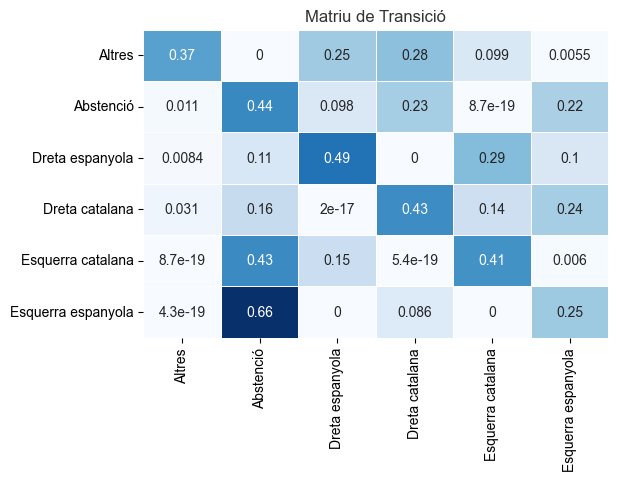

In [15]:
from utils import StableMarkovChain

mc = StableMarkovChain(df)
mc.fit()

print(mc)
mc.plot_transition_matrix()

Altres                0.017630
Abstenció             0.381232
Dreta espanyola       0.113084
Dreta catalana        0.192187
Esquerra catalana     0.106371
Esquerra espanyola    0.189496
dtype: float64


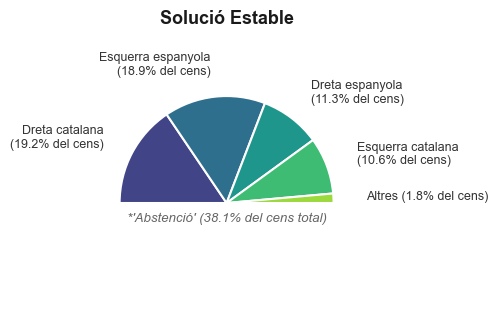

In [16]:
print(mc.get_steady_state())
mc.plot_steady_state()

In [17]:
"""import numpy as np

eigenvalues, eigenvectors = np.linalg.eig(df_P_final)

# Trobar l'índex de l'autovalor més proper a 1
idx = np.argmin(np.abs(eigenvalues - 1))

# Extreure el vector i normalitzar (suma = 1)
pi = np.real(eigenvectors[:, idx])
pi = pi / pi.sum()

partits = list(df_P_final.columns)
for p, v in zip(partits, pi):
    print(f"{p:10s}: {v:.4f}")

###### COMPROVACIÓ DE LA DISTRIBUCIÓ ESTACIONÀRIA ######
print("\nComprovació de la distribució estacionària:")
print(np.allclose(df_P_final @ pi, pi))  # Ha de donar True
print(pi.sum())                    # Ha de donar 1.0"""

'import numpy as np\n\neigenvalues, eigenvectors = np.linalg.eig(df_P_final)\n\n# Trobar l\'índex de l\'autovalor més proper a 1\nidx = np.argmin(np.abs(eigenvalues - 1))\n\n# Extreure el vector i normalitzar (suma = 1)\npi = np.real(eigenvectors[:, idx])\npi = pi / pi.sum()\n\npartits = list(df_P_final.columns)\nfor p, v in zip(partits, pi):\n    print(f"{p:10s}: {v:.4f}")\n\n###### COMPROVACIÓ DE LA DISTRIBUCIÓ ESTACIONÀRIA ######\nprint("\nComprovació de la distribució estacionària:")\nprint(np.allclose(df_P_final @ pi, pi))  # Ha de donar True\nprint(pi.sum())                    # Ha de donar 1.0'

Per al Teorema de Perron-Frobenius, una cadena de Markov irreductible i aperiòdica sempre té una única distribució estacionària π > 0.

In [18]:
mc.verify_steady_state()

VERIFICACIÓ DE L'EXISTÈNCIA DE LA DISTR. ESTACIONÀRIA

1. Matriu estocàstica:
   · Sumes de cada fila: [1. 1. 1. 1. 1. 1.]
   · Files sumen 1:      True
   · Valors no negatius: True

2. Irreductibilitat (tots els estats es comuniquen): True

3. Aperiodicitat (self-loops a la diagonal): True
   → La cadena és APERIÒDICA

EXISTEIX distribució estacionària ÚNICA


True

### Efecte d'una campanya
Per fer-ho canviem un valor de la matriu de transició, augmentant el nombre de votants que es queden del partit politic que fa la campanya.

In [19]:
fila = "Esquerra espanyola"
mc.transition_matrix.loc[fila, fila] = 0.6

# Renormalitzem la fila
mc.transition_matrix.loc[fila] /= mc.transition_matrix.loc[fila].sum()

# Verifiquem que segueix sumant 1
print(mc.transition_matrix.loc[fila].sum())

1.0


Altres                0.016535
Abstenció             0.357555
Dreta espanyola       0.106061
Dreta catalana        0.180250
Esquerra catalana     0.099764
Esquerra espanyola    0.239835
dtype: float64


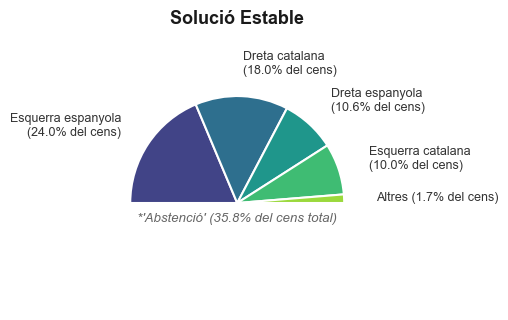

In [20]:
print(mc.get_steady_state())
mc.plot_steady_state()